# Tutorial 3 - LUPA

The main goal of this tutorial is to demonstrate how to set up a WEC design problem with a more complex and realistic setup.
We use the [Lab Upgrade Point Absorber (LUPA)](https://pmec-osu.github.io/LUPA/) device, an open source two-body heaving point absorber under development by Oregon State University.
A deep dive video demonstration of the LUPA device and its features can be viewed [here](https://www.youtube.com/watch?v=gCcAu7H9lQI).
We will numerically replicate LUPA testing in the Large Wave Flume at the [O.H. Hinsdale Wave Research Laboratory](https://engineering.oregonstate.edu/wave-lab) in order to provide further design optimization for the WEC device concept.
This tutorial builds on the previous ones by introducing:
 
* a WEC comprised of multiple bodies
* setting up a WEC with multiple degrees of freedom (DOF) using generalized modes
* more complex PTO kinematics that depend on more than one WEC DOF 
* realistic constraints including generator maximum and continuous torque, and maximum rotational speed
* irregular waves
* mooring system dynamics

A secondary goal for this tutorial is to serve as a tool for those who are planning to run experiments with the LUPA device, to inform their experiment design.  

As with previous tutorials, this tutorial consists of two parts, with the second section building upon the first.

1. [Optimal control of a two-body WEC](#1.-Optimal-control-of-a-two-body-WEC)
2. [Control co-design of the PTO sprocket sizing for maximum electrical power](#2.-Control-co-design-of-the-PTO-sprocket-sizing-for-maximum-electrical-power)

<p><img src=https://live.staticflickr.com/65535/52793669495_72ba57da99_z.jpg alt="Digital rendering of the LUPA" width="307"> <img src=https://live.staticflickr.com/65535/52792718812_b750791167_k.jpg alt="Picture of the LUPA floating in the flume in calm water. Both bodies and mooring are visible." width="500"> <img src=https://live.staticflickr.com/65535/52793276446_9b35889ccd_k.jpg alt="Picture of the LUPA in the dry flume. Both bodies and mooring are visible. A ladder and person next to it gives context of the scale." width="500"></p>

In [1]:
import os

import gmsh, pygmsh
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from scipy.optimize import brute
from wavespectra.construct.frequency import pierson_moskowitz

import wecopttool as wot

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging 
logging.getLogger().setLevel(logging.INFO)

import jax

## 1. Optimal control of a two-body WEC

### WEC geometry
The creation of the `WEC` object is fundamentally identical to previous tutorials, where we use meshes of the WEC to create Capytaine `FloatingBody` objects, run BEM using Capytaine, and use the `WEC.from_bem()` method to create the `WEC` object.
The key here is that the LUPA is a two-body device (consisting of a float and a spar), which move independently in heave but in unison for all other degrees of freedom.
To model this in WecOptTool, we can create a `FloatingBody` object for each body separately with a heave DOF, combine them into a single object afterwards, and be sure the combined mass and inertia properties are properly set.

We will analyze the device in its four planar degrees of freedom:

* Heave of the buoy
* Heave of the spar
* Combined device surge
* Combined device pitch

Here we are using the generalized modes approach; an alternative solution would be to include all 3 planar DOF for each body separately and add two constraints for the pitch and surge to be equal for both bodies.

#### LUPA properties
The mass properties of the LUPA have been provided from measurements of the physical device by Oregon State University, as follows:

In [2]:
# provided by OSU
float_mass_properties = {
    'mass': 248.721,
    'CG': [0.01, 0, 0.06],
    'MOI': [66.1686, 65.3344, 17.16],
}

spar_mass_properties = {
    'mass': 175.536,
    'CG': [0, 0, -1.3],
    'MOI': [253.6344, 250.4558, 12.746],
}

water_depth = 2.7 # depth of wave flume

#### Mesh creation of the float

Here we create the mesh based on the dimensions provided by Oregon State University using `pygmsh`, available [here](https://pypi.org/project/pygmsh/).
This is the same package used by `geom.py` (click [here](https://sandialabs.github.io/WecOptTool/api_docs/wecopttool.geom.html) for API documentation) containing the predefined WaveBot and AquaHarmonics meshes used in the previous tutorials.

The float has a hole where the spar passes through it. 
In previous versions of this tutorial, the hole was larger than the spar and led to a large spike in the BEM results. 
The spike has been resolved by making the hole smaller so that the float is flush with the spar.
Like the other tutorials, a lid is added to remove any irregular frequency spikes. 

In [3]:
# mesh
mesh_size_factor = 0.3
r1 = 1.0/2  # top radius
r2 = 0.4/2  # bottom radius
h1 = 0.5  
h2 = 0.21
freeboard = 0.3
r3 = 0.05  # hole radius
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    cyl = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    cone = geom.add_cone([0, 0, -h1], [0, 0, -h2], r1, r2)
    geom.translate(cyl, [0, 0, freeboard])
    geom.translate(cone, [0, 0, freeboard]) 
    tmp = geom.boolean_union([cyl, cone])
    bar = geom.add_cylinder([0, 0, 10], [0,0,-20], r3)
    geom.boolean_difference(tmp, bar)
    mesh_float = geom.generate_mesh()

Again, we will only add the heave DOF for now.
The surge and pitch will be added after we combine the two `FloatingBody` objects.

In [4]:
# lid
mesh_obj = load_from_meshio(mesh_float, 'float')
lid_mesh = mesh_obj.generate_lid(z=-1e-2)

# floating body
float_fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="float")
#float_fb.add_translation_dof(name='Heave')

INFO:capytaine.io.meshio:Stored 3858 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="float"), lid_mesh=Mesh(..., name="lid for float"), dofs={}, name="float").


We can now visualize the mesh:

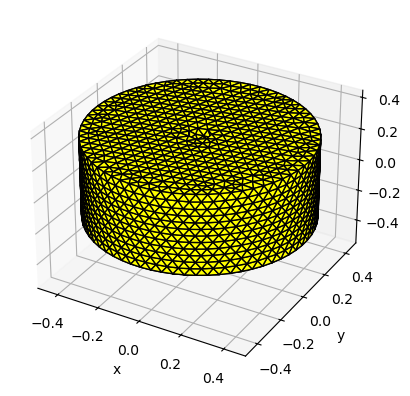

In [5]:
# show
float_fb.show_matplotlib()

# interactive, close pop-up image before being able to continue running the notebook
# float_fb.show()

#### Mesh creation of the spar

We now create the spar mesh in the same way as for the float, with the dimensions given by Oregon State University.

<p><img src=https://live.staticflickr.com/65535/52793722023_cd0b2e5d4f_k.jpg alt="spar dimensions schematic from OSU" width=700></p>

In [6]:
# mesh
mesh_size_factor = 0.1
r1 = 0.45/2  # body
r2 = 0.45  # plate
r3 = 0.10/2  # bar
h1 = 1.20  
h2 = 0.01
h3a = 3.684 - 2.05
submergence = 2.05 - h1 - h2

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    body = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    geom.translate(body, [0, 0, -submergence])
    plate = geom.add_cylinder([0, 0, 0], [0, 0, -h2], r2)
    geom.translate(plate, [0, 0, -(submergence+h1)])
    bar = geom.add_cylinder([0, 0, h3a], [0, 0, -(h3a+submergence)], r3)
    geom.boolean_union([bar, body, plate])
    mesh_spar = geom.generate_mesh()

In [7]:
# lid
mesh_obj = load_from_meshio(mesh_spar, 'float')
lid_mesh = mesh_obj.generate_lid(z=-1e-2)

# floating body
spar_fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="spar")
#spar_fb.add_translation_dof(name='Heave')

INFO:capytaine.io.meshio:Stored 6274 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="float"), lid_mesh=Mesh(..., name="lid for float"), dofs={}, name="spar").


(-0.44989582589095095, 0.4498958258909509)

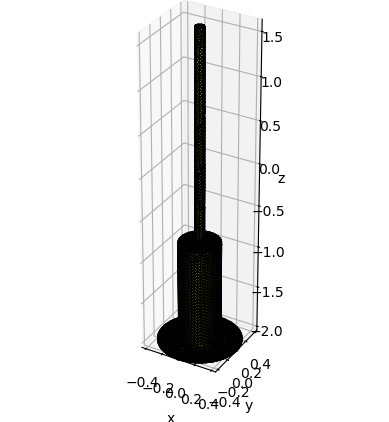

In [8]:
# show
fig = plt.figure()
xmin, xmax, ymin, ymax, zmin, zmax = spar_fb.mesh.axis_aligned_bbox
scalez = (zmax-zmin) / (xmax-xmin)
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect(aspect=(1,1,scalez))
spar_fb.show_matplotlib(ax=ax)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# interactive, close pop-up image before being able to continue running the notebook
# spar_fb.show()

#### Combined `FloatingBody`

With both WEC bodies defined separately, we can now define the respective centers of mass and rotation centers of the bodies.
We will then create a union of the bodies and define the properties for the overall LUPA device.
At the equilibrium position the float is neutrally buoyant while the spar is positively buoyant and requires mooring pre-tension.
The combined center of mass and moment of inertia can be found by using the given values weighted by the mass (via the parallel axis theorem for the moment of inertia).
This is also when we can specify the surge and pitch degrees of freedom.

We are using the density of *fresh* water, $\rho = 1000 kg/m^3$, since we are modeling LUPA in a wave flume.

In [9]:
# density of fresh water
rho = 1000

# mass properties float
#mass_float = float_mass_properties['mass']
cm_float = np.array(float_mass_properties['CG'])
#pitch_inertia_float = float_mass_properties['MOI'][1]
float_fb.center_of_mass = cm_float
float_fb.rotation_center = float_fb.center_of_mass

float_fb.add_translation_dof(name='Surge')
float_fb.add_translation_dof(name='Heave')
float_fb.add_rotation_dof(name='Pitch')
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag(
    [float_mass_properties['mass'],float_mass_properties['mass'], float_mass_properties['MOI'][1]]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(float_fb.dofs),
                                    'radiating_dof': list(float_fb.dofs)},
                            name="inertia_matrix")

float_fb.inertia_matrix = rigid_inertia_matrix_xr
float_fb.hydrostatic_stiffness = float_fb.immersed_part().compute_hydrostatic_stiffness()

# mass properties spar
#mass_spar = spar_mass_properties['mass']
cm_spar = np.array(spar_mass_properties['CG'])
#pitch_inertia_spar = spar_mass_properties['MOI'][1]
spar_fb.center_of_mass = cm_spar
spar_fb.rotation_center = spar_fb.center_of_mass

spar_fb.add_translation_dof(name='Surge')
spar_fb.add_translation_dof(name='Heave')
spar_fb.add_rotation_dof(name='Pitch')
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([
    spar_mass_properties['mass'],spar_mass_properties['mass'], spar_mass_properties['MOI'][1]]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(spar_fb.dofs),
                                    'radiating_dof': list(spar_fb.dofs)},
                            name="inertia_matrix")

spar_fb.inertia_matrix = rigid_inertia_matrix_xr
spar_fb.hydrostatic_stiffness = spar_fb.immersed_part().compute_hydrostatic_stiffness()

# floating body
lupa_fb = float_fb + spar_fb
lupa_fb.name = 'LUPA'

INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="float").rotation_center = [0.01 0.   0.06]
INFO:capytaine.bodies.bodies:Clipping float with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping lid for float by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:Clipping spar with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping lid for float by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="float+spar_mesh"), lid_mesh=CollectionOfMeshes(..., name="float+spar_lid_mesh"), dofs={"float__Surge": ..., "float__Heave": ..., "float__Pitch": ..., "spar__Surge

#### Define Hydrostatics Manually
We need to be carefully set up the hydrostatic correctly when combining multiple bodies.
The bodies move separately in heave but move together in surge and pitch.
Therefore, we should define the individual heave inertia values _for each body_, but define the _total_ surge and pitch inertia values.
The inertia then needs to be reformatted as an `xarray.DataArray` to work with Capytaine.
The hydrostatic stiffness can be calculated for the total immersed body.

We can now visualize the combined mesh.

(-0.4999214318270731, 0.4999248213210051)

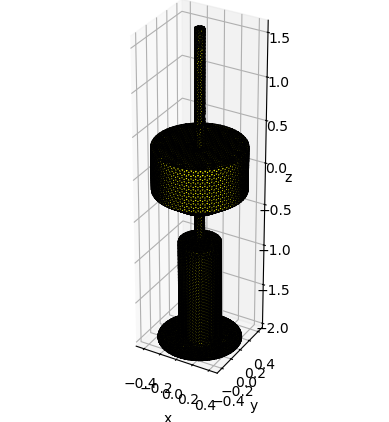

In [10]:
# show
fig = plt.figure()
xmin, xmax, ymin, ymax, zmin, zmax = lupa_fb.mesh.axis_aligned_bbox
scalez = (zmax-zmin) / (xmax-xmin)
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect(aspect=(1,1,scalez))
lupa_fb.show_matplotlib(ax=ax)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# lupa_fb.show()

### Waves
Oregon State University has defined two sets of wave testing conditions for the LUPA: one corresponding to the PacWave South site and a scaling factor of 25, and one for the PacWave North site and a scaling factor of 20. 
For each site/scale they provide four wave conditions to test at the Oregon State Large Wave Flume (LWF): the maximum 90<sup>th</sup> percentile, maximum percent annual energy, maximum occurrence, and minimum 10<sup>th</sup> percentile. 

In this tutorial we will use the PacWave South conditions scaled to the LWF and will design for the maximum occurrence wave. 
The wave conditions are specified in terms of significant wave height and peak period. Waves are mostly fully developed at the PacWave site, so we will use a Pierson-Moskowitz wave spectrum. 

The irregular wave is created with multiple phase realizations.
The solver will be run once for each wave phase realization.
Each of these phase realizations leads to a slightly different result for optimal average power.
Thus, for irregular wave conditions, it is recommended to include multiple phase realizations.
The number of phase realizations required is dependent on the desired accuracy of the result, but it is generally recommended to include enough realizations for the total simulation time to equal 20 minutes.
For this tutorial, the number of realizations has been set to 2 to reduce the total runtime. 

$$ t_{total} = \frac{n_{realizations}}{f_1} $$

Because we are now using irregular waves, we need significantly more frequencies to capture the entire wave spectrum and WEC response. 

In [11]:
waves = {}

wavefreq = 0.4
f1 = wavefreq
nfreq = 10
freq = wot.frequency(f1, nfreq, False)

# regular (for testing/setup)
amplitude = 0.1
phase = 0
wavedir = 0
waves['regular'] = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

nrealizations = 1

### BEM
With the LUPA geometry and physical properties fully defined, we can now run Capytaine to calculate the hydrodynamic coefficients of the device, as done in previous tutorials.
Capytaine can handle generalized modes and will calculate the coefficients for our 4 degrees of freedom.
The BEM coefficients have been pre-calculated and are saved in a file.
To re-run the BEM, which takes about 1 hour, simply move or delete the existing `data/bem.nc` file.

In [12]:
# read BEM data file if it exists
filename = 'data/LUPA_bem_reg_6dof.nc'
try:
    bem_data = wot.read_netcdf(filename)
except:
    bem_data = wot.run_bem(lupa_fb, freq, rho=rho, depth=water_depth)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(filename, bem_data)

We now visualize the BEM results.
An irregular frequency at about 5.25 rad/s is visible in many of the plots, but this should not substantially impact our model as the wave energy at this frequency is fairly low. 

[(<Figure size 1800x1800 with 21 Axes>,
  array([[<Axes: title={'center': 'float__Surge'}, ylabel='float__Surge'>,
          <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='float__Heave'>,
          <Axes: title={'center': 'float__Heave'}>, <Axes: >, <Axes: >,
          <Axes: >, <Axes: >],
         [<Axes: ylabel='float__Pitch'>, <Axes: >,
          <Axes: title={'center': 'float__Pitch'}>, <Axes: >, <Axes: >,
          <Axes: >],
         [<Axes: ylabel='spar__Surge'>, <Axes: >, <Axes: >,
          <Axes: title={'center': 'spar__Surge'}>, <Axes: >, <Axes: >],
         [<Axes: ylabel='spar__Heave'>, <Axes: >, <Axes: >, <Axes: >,
          <Axes: title={'center': 'spar__Heave'}>, <Axes: >],
         [<Axes: xlabel='$\\omega$', ylabel='spar__Pitch'>,
          <Axes: xlabel='$\\omega$'>, <Axes: xlabel='$\\omega$'>,
          <Axes: xlabel='$\\omega$'>, <Axes: xlabel='$\\omega$'>,
          <Axes: title={'center': 'spar__Pitch'}, xlabel='$\\omega$'>]],
       

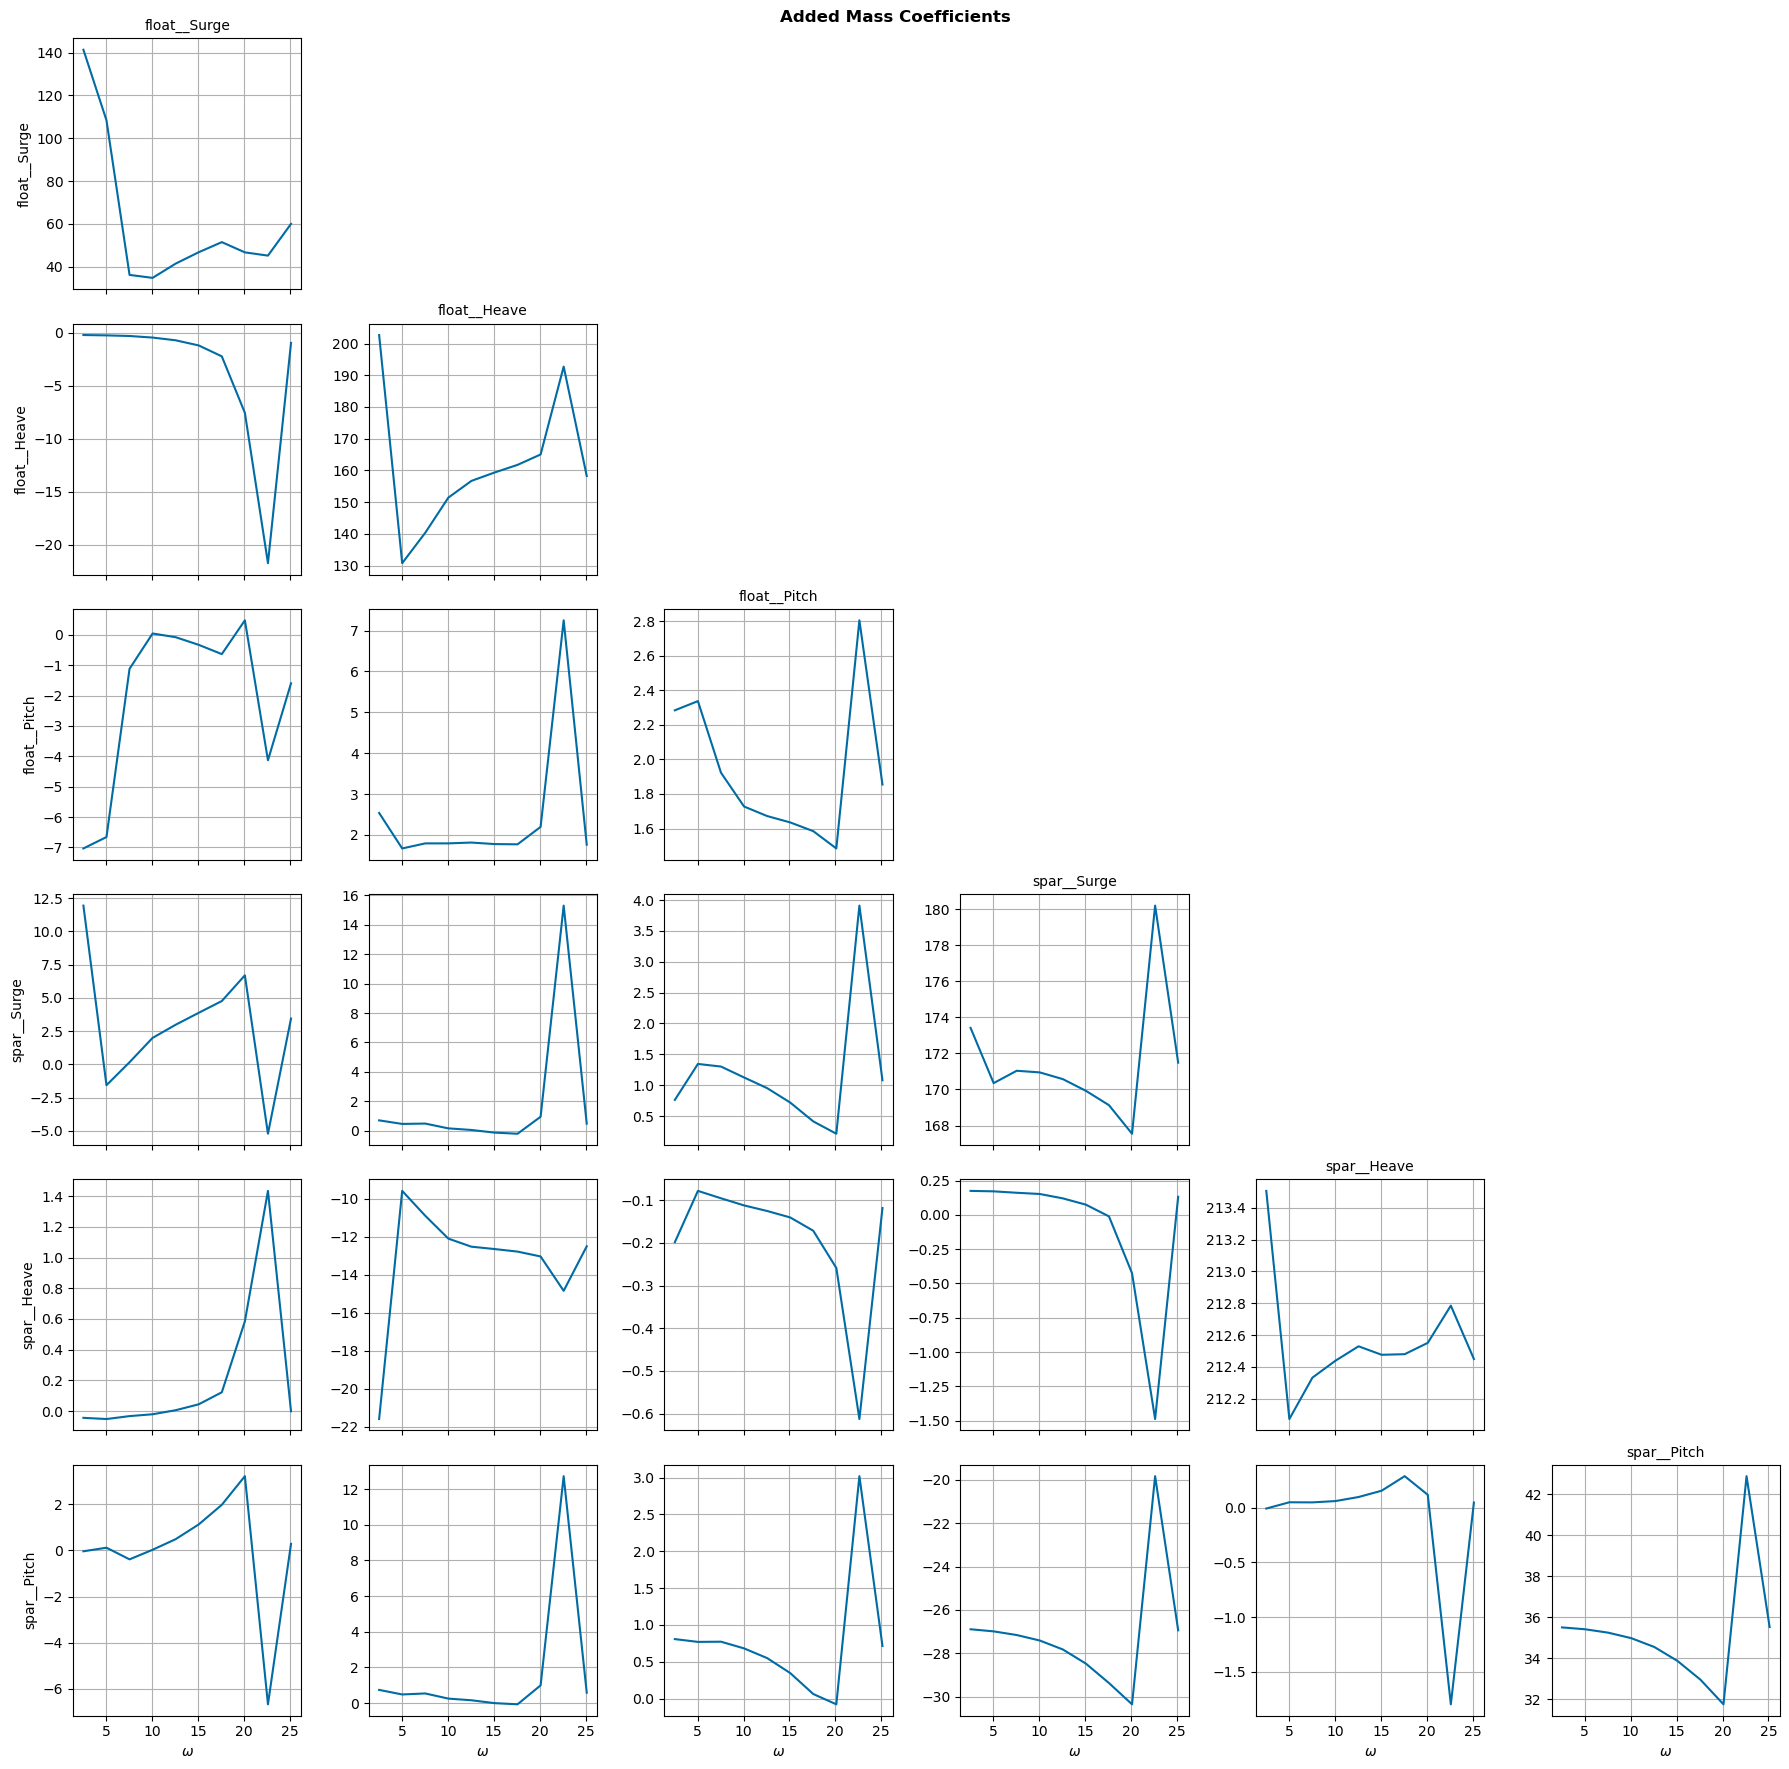

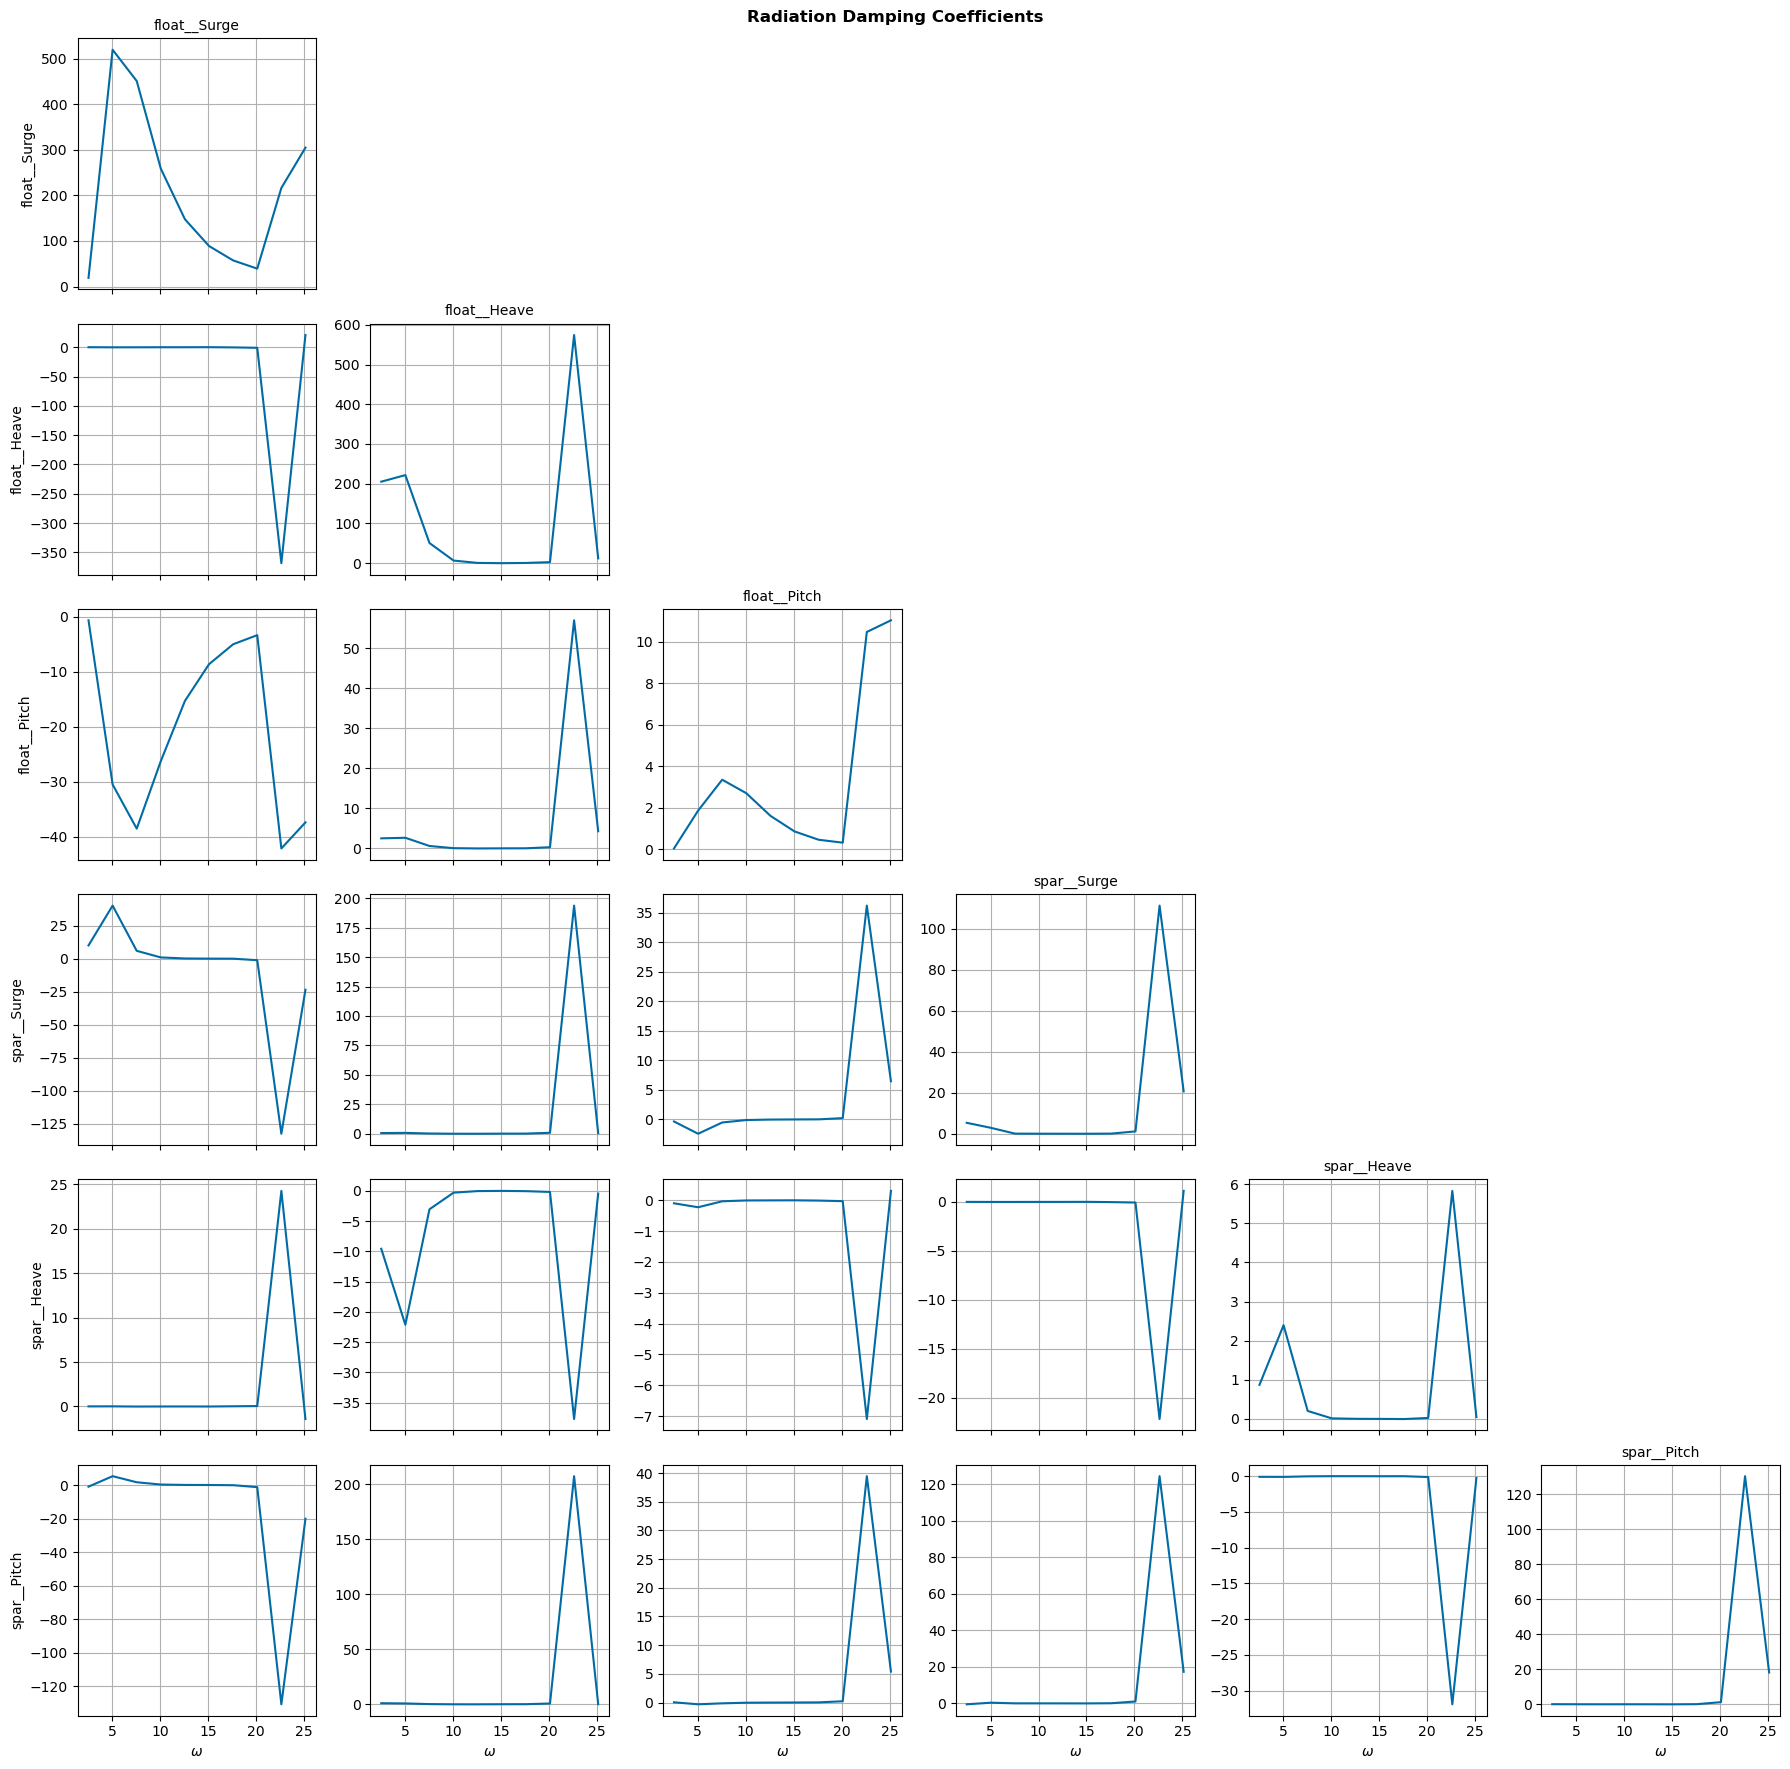

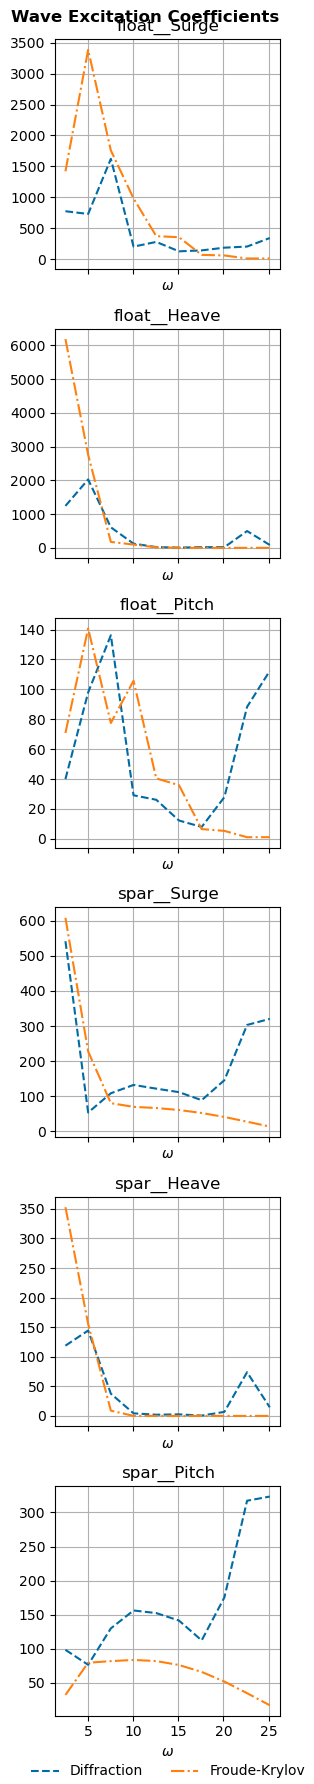

In [13]:
wot.utilities.plot_hydrodynamic_coefficients(bem_data)

In [14]:
# add small stiffness in surge 
stiffness = np.diag([1, 0, 0, 1, 0, 0])

#########################################
# Solve using wec opt tool

def surge_stiffness(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    stiffness_var = -pos @ stiffness
    stiffness_force = jnp.dot(time_matrix,stiffness_var)
    return stiffness_force

In [15]:
# add constraints to couple bodies in 6 dofs

mass_float = float_mass_properties['mass']
mass_spar = spar_mass_properties['mass']
cm_lupa = ((mass_float*cm_float + mass_spar*cm_spar)
                        / (mass_float + mass_spar))
cg_diff_float = cm_float - cm_lupa
cg_diff_spar = cm_spar - cm_lupa

def const_surge(wec, x_wec, x_opt, wave, nsubsteps=1): # Format for scipy.optimize.minimize
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    pos_td = jnp.dot(time_matrix,pos)

    lupa_cg_surge_from_float = pos_td[:,0] + cg_diff_float[2] * pos_td[:,2]
    lupa_cg_surge_from_spar = pos_td[:,3] + cg_diff_spar[2] * pos_td[:,5]
    return jnp.abs(lupa_cg_surge_from_float - lupa_cg_surge_from_spar).flatten()

def const_pitch(wec, x_wec, x_opt, wave, nsubsteps=1): # Format for scipy.optimize.minimize
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    pos_td = jnp.dot(time_matrix,pos)
    jax.debug.print("pos_td shape = {}", pos_td.shape)
    return jnp.abs(pos_td[:,2] - pos_td[:,5]).flatten()

### WEC object

We are now ready to create our full WEC object. 

In [16]:
friction = None

constraints = [{'type': 'ineq', 'fun': const_pitch}] #{'type': 'ineq', 'fun': const_surge}, 
f_add = {'stiffness':surge_stiffness}

# WEC
wec = wot.WEC.from_bem(bem_data,
                       constraints=constraints,
                       friction=friction,
                       f_add=f_add,
                       dof_names=bem_data.influenced_dof.values,
)

[09:57:22] WARNING  Linear damping for DOF "spar__Surge" has negative or close to zero terms. Shifting up damping  
                    terms [5] to a minimum of 1e-06 N/(m/s)

           WARNING  Linear damping for DOF "spar__Heave" has negative or close to zero terms. Shifting up damping  
                    terms [5 6] to a minimum of 1e-06 N/(m/s)

           WARNING  Linear damping for DOF "spar__Pitch" has negative or close to zero terms. Shifting up damping  
                    terms [2 5] to a minimum of 1e-06 N/(m/s)

### Solve
We now solve the inner optimization for optimal control strategy for a fixed design.

In a formal design case, it is good practice to first test the setup with a regular wave case to confirm the WEC is responding as expected.
We have performed this step, but skip it here for the sake of brevity.
To run the regular wave, change the wave selection in the code below. 

In [ ]:
# Objective function
#obj_fun = pto.average_power
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = wec.ncomponents

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves['regular'], # waves['south_max_occurrence'], #
    obj_fun, 
    nstate_opt, 
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)
power_results = [result.fun for result in results]
print(f'Optimal average electrical power: {np.mean(power_results)} W')

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.


In [ ]:
# Post-process
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves['regular'], nsubsteps)
#pto_fdom, pto_tdom = pto.post_process(wec, results, waves['regular'], nsubsteps)

pos_td shape = (Array(100, dtype=int64, weak_type=True), Array(6, dtype=int64, weak_type=True))


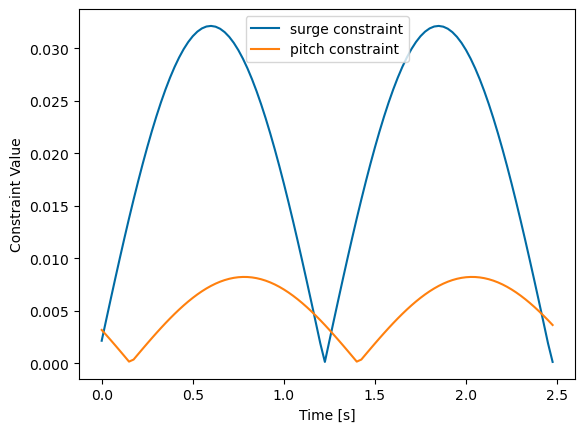

In [ ]:
# check constraints
ndof = 6
x_wec, x_opt = wot.decompose_state(results[0].x, ndof, nfreq)
wave = waves['regular']
surge_con = const_surge(wec, x_wec, x_opt, wave, nsubsteps)
pitch_con = const_pitch(wec, x_wec, x_opt, wave, nsubsteps)

plt.figure()
plt.plot(wec_tdom['time'], surge_con, label='surge constraint', color='C0')
plt.plot(wec_tdom['time'], pitch_con, label='pitch constraint', color='C1')
plt.xlabel('Time [s]')
plt.ylabel('Constraint Value')
plt.legend()
plt.show()

### Results
The `post_process` functions return lists of post-processed results. Here, we extract the first element of each list to analyze the results for the first wave phase realization. Looking at the response of the optimal solution, we can see the behavior of the WEC and its relationship to our problem constraints:

* __PTO position__ - The PTO position corresponds to the difference in the vertical position between the two bodies.
The PTO position is clearly nowhere near the 0.5 m maximum stroke, so the constraint is not plotted here.
* __Excitation force and velocity__ - Much like Tutorial 2, we would expect the excitation force and velocity of each body to be in phase when maximizing for mechanical power and in the absence of constraints.
Given the constraints on the PTO, this is not the case here, with the spar velocity being out of phase with the wave excitation acting on it.
This indicates the differences when maximizing for mechanical vs. electrical power for LUPA in these wave conditions.
It is also clear that the velocities (or their rotational equivalents) are nowhere near the generator maximum speed.
* __Generator torque__ - This plot shows that both of the torque constraints are active for this wave case, and dominate the solution given the lack of relevance of the other constraints above.
The PTO RMS torque is well within the continuous torque limit, and the generator exceeds the RMS limit for only brief period.
The peak torque limit is approached at a few moments as well.
* __Power__ - As expected, the greatest power absorption aligns with the times of greatest PTO velocity and peak torque magnitude. 

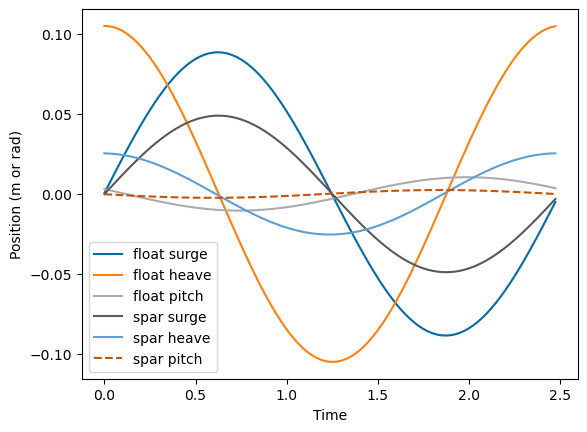

In [ ]:
plt.figure()
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='float__Surge')), label='float surge', color='C0')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='float__Heave')), label='float heave', color='C1')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='float__Pitch')), label='float pitch', color='C2')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='spar__Surge')), label='spar surge', color='C3')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='spar__Heave')), label='spar heave', color='C4')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='spar__Pitch')), label='spar pitch', color='C5', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Position (m or rad)')
plt.legend()
plt.show()

In [ ]:
plt.figure()
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='Surge')), label='surge', color='C0')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='float__Heave')), label='float heave', color='C2')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='spar__Heave')), label='spar heave', color='C3')
plt.plot(wec_tdom['time'], np.squeeze(wec_tdom['pos'].sel(influenced_dof='Pitch')), label='pitch', color='C4')
plt.xlabel('Time')
plt.ylabel('Position (m or rad)')
plt.legend()
plt.show()

KeyError: "not all values found in index 'influenced_dof'. Try setting the `method` keyword argument (example: method='nearest')."

<Figure size 640x480 with 0 Axes>

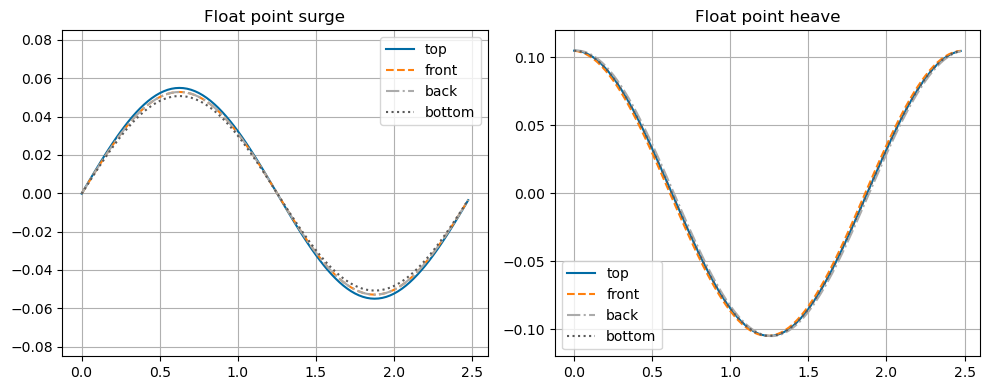

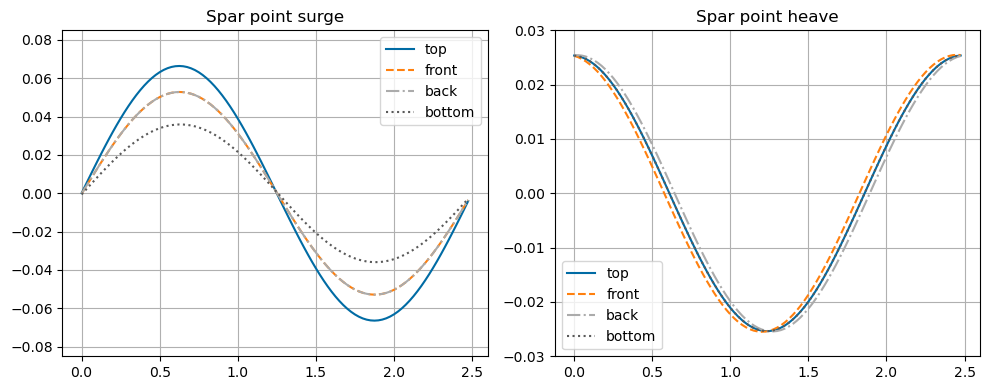

In [ ]:
def point_motion_2d(surge, heave, pitch, x_rel, z_rel):
    ux = surge + z_rel * pitch
    uz = heave - x_rel * pitch
    return ux, uz

def plot_body_points_direct(wec_tdom, points, body, realization=0, ylim_surge=None, ylim_heave=None):
    ds = wec_tdom.sel(realization=realization)

    s = ds.pos.sel(influenced_dof='Surge')
    p = ds.pos.sel(influenced_dof='Pitch')

    if body.lower() == "float":
        h = ds.pos.sel(influenced_dof='float__Heave')
    elif body.lower() == "spar":
        h = ds.pos.sel(influenced_dof='spar__Heave')
    else:
        raise ValueError("body must be 'float' or 'spar'")
    
    linestyles = ['-', '--', '-.', ':']
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    for i, (name, (x_rel, z_rel)) in enumerate(points.items()):
        ls = linestyles[i % len(linestyles)]
        ux, uz = point_motion_2d(s, h, p, x_rel, z_rel)
        axs[0].plot(ds.time, ux, label=name, linestyle=ls)
        axs[1].plot(ds.time, uz, label=name, linestyle=ls)

    axs[0].set_title(f"{body.capitalize()} point surge")
    axs[1].set_title(f"{body.capitalize()} point heave")

    if ylim_surge is not None:
        axs[0].set_ylim(ylim_surge)
    if ylim_heave is not None:
        axs[1].set_ylim(ylim_heave)

    for ax in axs:
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

points_float = {
    "top": (0.0, 0.25),
    "front": (0.4, 0.0),
    "back": (-0.4, 0.0),
    "bottom": (0.0, -0.25),
}

points_spar = {
    "top": (0.0, 1.6),
    "front": (0.25, 0.0),
    "back": (-0.25, 0.0),
    "bottom": (0.0, -2.0),
}

plot_body_points_direct(wec_tdom, points_float, body="float", ylim_surge=(-0.085, 0.085), ylim_heave=(-0.12, 0.12))
plot_body_points_direct(wec_tdom, points_spar, body="spar", ylim_surge=(-0.085, 0.085), ylim_heave=(-0.03, 0.03))

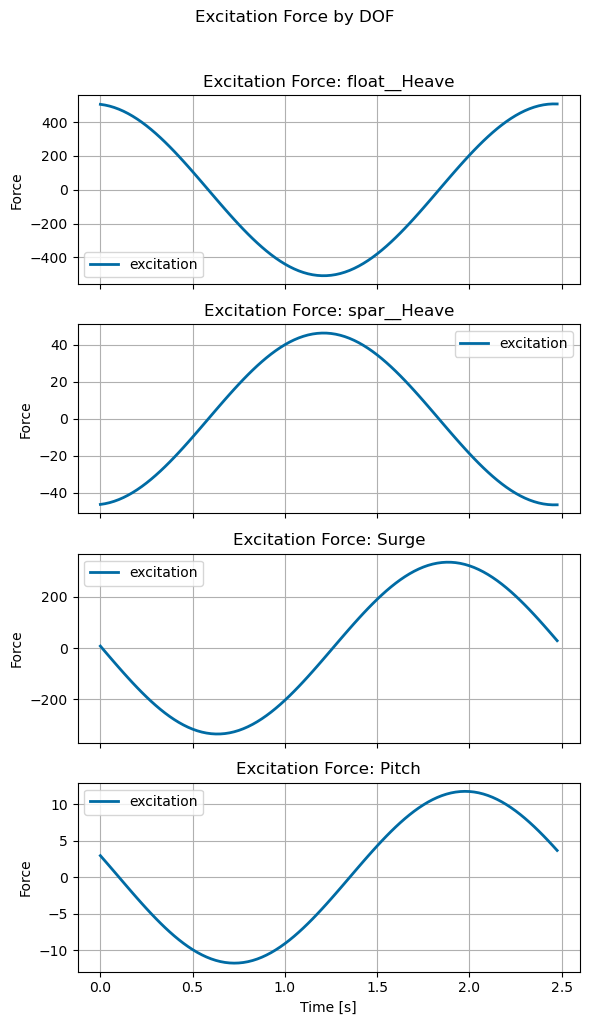

In [ ]:
# Select first realization
ds = wec_tdom.sel(realization=0)

# Compute excitation force = diffraction + Froude_Krylov
f_exc = (
    ds.force.sel(type="diffraction") +
    ds.force.sel(type="Froude_Krylov")
)

times = ds.time.values
dofs = ds.influenced_dof.values

# Create one subplot per DOF
fig, axes = plt.subplots(len(dofs), 1, figsize=(6, 2.5 * len(dofs)), sharex=True)

if len(dofs) == 1:
    axes = [axes]

for ax, dof in zip(axes, dofs):
    y = f_exc.sel(influenced_dof=dof).values
    ax.plot(times, y, label="excitation", linewidth=2)
    ax.set_title(f"Excitation Force: {dof}")
    ax.set_ylabel("Force")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time [s]")
fig.suptitle("Excitation Force by DOF", y=1.02)
fig.tight_layout()
plt.show()